In [1]:
import numpy as np 
import pandas as pd 
import statistics as sts 
from matplotlib import pyplot as plt 
import streamlit as st 
import joblib 
from sklearn.preprocessing import PowerTransformer,LabelEncoder,StandardScaler
from sklearn.model_selection import cross_val_score,GridSearchCV,train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest,f_regression,f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer

In [2]:
df1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\machineLearning1\pred09\final_test.csv",encoding_errors='ignore')

In [3]:
df2=df1.copy()

In [4]:
def main_function(df2):
    print("===================")
    print(df2.ndim)
    print("===================")
    print(df2.shape)
    print("===================")
    print(df2.size)
    print("===================")
    print(df2.describe())
    print("===================")
    print(df2.info())
    print("===================")
    print(df2.isna().sum())
    print("===================")
    print(df2.isnull().sum())
    print("===================")
main_function(df2)

2
(119734, 4)
478936
              weight            age         height
count  119734.000000  119477.000000  119404.000000
mean       61.756811      34.027311     165.805794
std         9.944863       8.149447       6.737651
min        22.000000       0.000000     137.160000
25%        55.000000      29.000000     160.020000
50%        61.000000      32.000000     165.100000
75%        67.000000      37.000000     170.180000
max       136.000000     117.000000     193.040000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119734 entries, 0 to 119733
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   weight  119734 non-null  int64  
 1   age     119477 non-null  float64
 2   height  119404 non-null  float64
 3   size    119734 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.7+ MB
None
weight      0
age       257
height    330
size        0
dtype: int64
weight      0
age       257
height    330
size

In [5]:
df2.drop_duplicates(inplace=True)

In [6]:
# df2.dropna(axis=0,how='any',inplace=True)

In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27404 entries, 0 to 119721
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   weight  27404 non-null  int64  
 1   age     27220 non-null  float64
 2   height  27150 non-null  float64
 3   size    27404 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 1.0+ MB


In [8]:
df2.isna().sum()

weight      0
age       184
height    254
size        0
dtype: int64

In [9]:
imputer=SimpleImputer(strategy='mean')
df2[['age']]=imputer.fit_transform(df2[['age']])

In [10]:
imputer=SimpleImputer(strategy='mean')
df2[['height']]=imputer.fit_transform(df2[['height']])

In [11]:
df2.sample(10)

,weight,age,height,size
6080,54,25.0,167.64,S
17949,50,28.0,157.48,S
9347,106,35.0,177.80,XXXL
18729,56,31.0,147.32,XXS
115598,62,26.0,160.02,L
8244,50,43.0,162.56,S
18847,48,40.0,154.94,S
88001,38,19.0,147.32,XXS
9355,63,23.0,165.10,L
19106,65,44.0,167.64,XL


In [12]:
df2['size'].value_counts().to_dict()

{'XXXL': 6768,
 'M': 4916,
 'XL': 4725,
 'L': 4236,
 'S': 4112,
 'XXS': 2580,
 'XXL': 67}

In [13]:
encoder=LabelEncoder()
df2['size_encoded']=encoder.fit_transform(df2['size'])

In [14]:
df2.sample(10)

,weight,age,height,size,size_encoded
132,63,30.0,165.10,XL,3
27472,53,26.0,167.64,XXS,5
7110,61,54.0,170.18,L,0
87563,62,36.0,167.64,XL,3
2891,54,27.0,167.64,M,1
24069,46,36.0,152.40,M,1
95538,47,45.0,152.40,M,1
24455,63,49.0,160.02,M,1
57030,58,20.0,160.02,L,0
52876,62,38.0,165.10,XL,3


In [15]:
df2.drop(columns=['size'],axis=1,inplace=True)

In [16]:
df2.sample(10)

,weight,age,height,size_encoded
14686,61,22.0,175.26,5
45391,57,36.0,154.94,1
31872,45,21.0,152.40,5
78936,53,38.0,149.86,1
1139,56,70.0,170.18,1
82623,61,26.0,180.34,0
24504,50,38.0,147.32,2
35433,56,56.0,160.02,1
26011,57,29.0,160.02,0
72479,50,31.0,152.40,2


<Axes: ylabel='Density'>

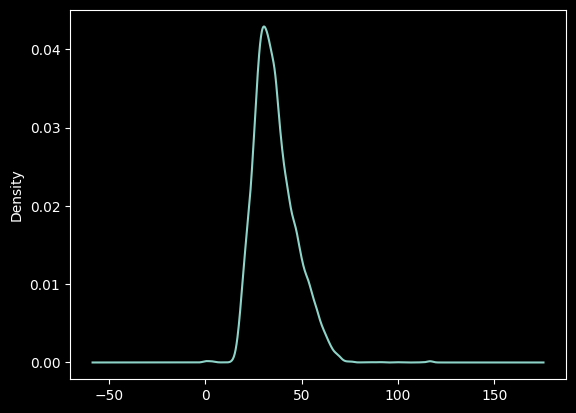

In [17]:
df2['age'].plot(kind='kde')

In [18]:
df2.skew().round(2)

weight          1.30
age             0.90
height          0.11
size_encoded    0.21
dtype: float64

<Axes: ylabel='Density'>

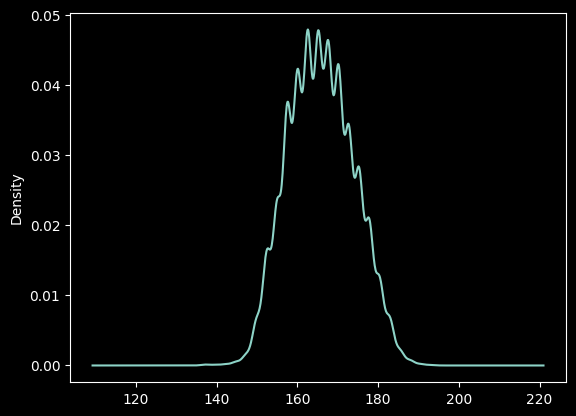

In [19]:
df2['height'].plot(kind='kde')

<Axes: ylabel='Density'>

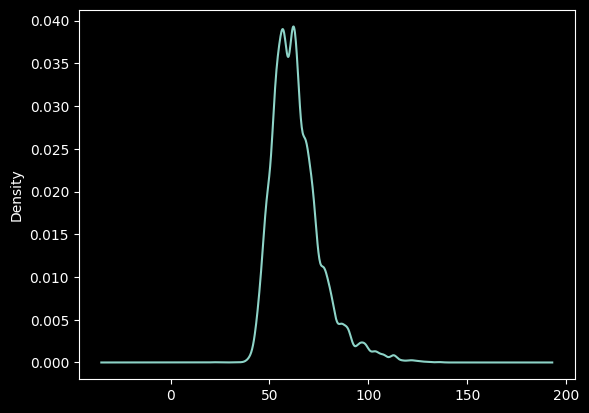

In [20]:
df2['weight'].plot(kind='kde')

In [21]:
power_skew=PowerTransformer(method='yeo-johnson')
df2[['weight','age','height']]=power_skew.fit_transform(df2[['weight','age','height']])

<Axes: ylabel='Density'>

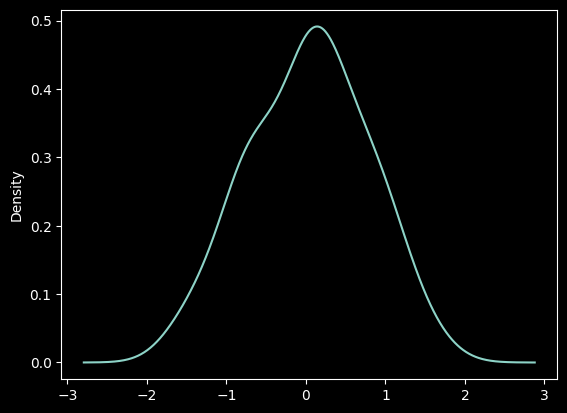

In [22]:
df2['height'].head(30).plot(kind='kde')

In [23]:
df2.corr(method='spearman').round(2)

,weight,age,height,size_encoded
weight,1.00,0.05,0.38,0.38
age,0.05,1.00,-0.01,0.05
height,0.38,-0.01,1.00,0.04
size_encoded,0.38,0.05,0.04,1.00


In [24]:
df2.corr(method='pearson').round(2)

,weight,age,height,size_encoded
weight,1.00,0.05,0.38,0.37
age,0.05,1.00,-0.01,0.05
height,0.38,-0.01,1.00,0.04
size_encoded,0.37,0.05,0.04,1.00


<Axes: >

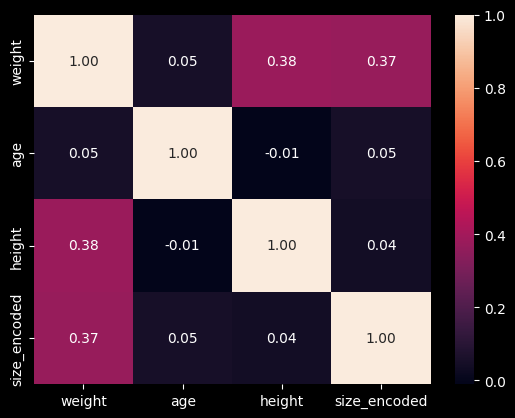

In [25]:
import seaborn as sns 


sns.heatmap(df2.corr(method='pearson').round(2),fmt=".2f",cbar=True,annot=True)


In [26]:
x=df2[['weight','age','height']]
y=df2['size_encoded']

In [43]:
important_features=SelectKBest(score_func=f_classif,k=2)
results=important_features.fit_transform(x,y)
results

array([[ 0.03426792,  0.8605344 ],
       [-0.25178343,  0.24468147],
       [-0.05804312, -0.06992542],
       ...,
       [ 0.29460994,  0.8605344 ],
       [-0.35351927,  0.24468147],
       [ 0.03426792, -0.71317783]], shape=(27404, 2))

In [28]:
selected_col=x.columns[important_features.get_support()]
selected_col

Index(['weight', 'height'], dtype='object')

In [42]:
selected_col_numeric=df2.select_dtypes(include='number',exclude='object').columns

selected_col_numeric

Index(['weight', 'age', 'height', 'size_encoded'], dtype='object')

In [30]:
import time
class AnomolieClass:
    def __init__(self,data):
        self.data=data 
    def anomolies_function(self,columns):
        Q1=self.data[columns].quantile(0.25)
        Q3=self.data[columns].quantile(0.75)
        IQR=Q3-Q1 
        loweer_bound=Q1-1.5*IQR 
        upper_bound=Q3+1.5*IQR 
        anomolies=[]
        for index, each_data in self.data[columns].items():
            if each_data < loweer_bound or each_data > upper_bound:
               anomolies.append(index) 
        return anomolies

AnomolieClass_instance=AnomolieClass(df2)
for each_column in df2.columns:
    anomolies_indexes=AnomolieClass_instance.anomolies_function(each_column)
    anomolies_count=len(anomolies_indexes)
    if anomolies_indexes:
        print(f"{each_column} and {anomolies_indexes} and count is \n {anomolies_count}")
        time.sleep(5)
        print("dropping the rows based on indexes")
        df3=df2.drop(anomolies_indexes)
    else:
        print(f"{each_column}")
        
print(f"{df2.shape} << - shape and {len(df2)}")
print(f"{df3.shape}<< - shape and {len(df3)}")   

weight and [924, 2365, 2704, 4273, 4557, 5640, 6609, 6942, 7298, 7919, 8449, 9986, 10370, 10423, 11901, 11986, 12994, 13184, 13954, 14303, 14393, 14603, 15730, 16764, 16827, 17057, 19379, 19669, 20179, 21728, 22203, 25028, 29021, 29177, 30201, 30996, 31945, 32076, 32269, 33356, 33717, 34628, 35380, 35679, 37825, 40013, 40027, 41002, 41946, 43439, 44772, 44949, 46591, 47023, 47098, 47824, 48277, 50305, 51184, 52336, 53330, 53491, 55582, 58068, 58918, 59496, 60857, 61669, 61776, 62798, 64560, 64563, 66523, 67067, 67622, 68511, 68639, 69879, 70357, 71295, 71882, 72061, 78408, 78498, 79473, 79608, 81610, 82853, 83810, 84560, 85576, 86319, 86589, 86995, 88001, 88219, 88415, 88633, 91566, 91883, 93189, 94171, 95165, 95802, 96566, 99206, 99263, 99758, 100275, 100384, 103817, 104382, 105639, 107959, 108521, 108982, 111296, 112821, 113267, 113848, 115608, 118562, 118675] and count is 
 123
dropping the rows based on indexes
age and [1261, 1905, 4076, 5553, 6111, 7064, 8291, 8404, 9103, 9146, 93

In [44]:
df2.sample(10)

,weight,age,height,size_encoded
16522,-0.567569,0.163888,0.244681,2
104792,0.123728,-0.123387,-2.060049,3
90350,-0.680257,-1.598118,-0.389165,2
73140,0.532571,0.436820,-1.376127,6
29288,0.952017,0.347325,1.752774,6
102317,0.034268,1.636373,-0.069925,1
9299,2.011229,-1.339789,-0.389165,6
61732,0.123728,-0.639966,0.554792,2
2505,-0.353519,-0.532419,-0.389165,2
3121,-1.043520,-0.323885,0.860534,2


<Axes: ylabel='weight'>

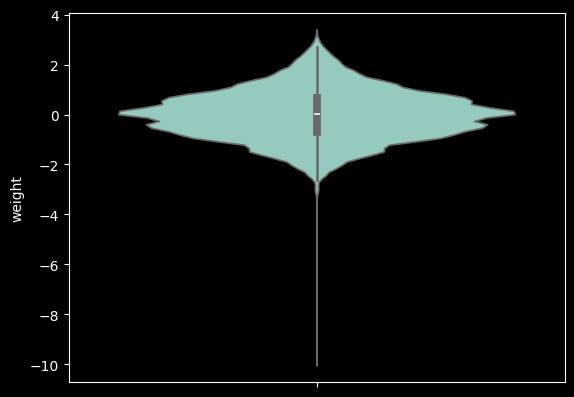

In [32]:
sns.violinplot(df2['weight'])

In [33]:
class threeSigmaMethod:
    def __init__(self,data):
        self.data=data 
    def anomolies1_function(self,column1):
        mean_value=sts.mean(self.data[column1])
        std_dev=sts.stdev(self.data[column1])
        cuttoff=3*std_dev
        lower_bound1=mean_value-cuttoff
        upper_bound1=mean_value+cuttoff
        anomlies1=[]
        for each_data1 in self.data[column1]:
            if each_data1 < lower_bound1 or each_data1 > upper_bound1:
                anomlies1.append(each_data1)
        return anomlies1
threeSigmaMethod_instance=threeSigmaMethod(df2)
for each_col1 in df2.columns:
    anomolies_data1=threeSigmaMethod_instance.anomolies1_function(each_col1)
    couting_anomolies=len(anomolies_data1)
    if anomolies_data1:
        print(f"{each_col1} and {anomolies_data1} --> \n{couting_anomolies}")
    else:
        print(f"{each_col1}")

weight and [-3.0205802853378154, -3.0205802853378154, -3.0205802853378154, -3.0205802853378154, 3.049812757834519, -3.0205802853378154, -3.0205802853378154, -9.783221415487745, -3.0205802853378154, -3.0205802853378154, -5.461774243825193, 3.1513402142981533, -3.0205802853378154, -3.0205802853378154, 3.049812757834519, -9.783221415487745, 3.1513402142981533, -3.0205802853378154, 3.049812757834519, -3.0205802853378154, -3.0205802853378154, -3.0205802853378154, -3.0205802853378154, 3.049812757834519, -3.0205802853378154, -4.227904864429906, -3.0205802853378154, 3.007041645668933, 3.1513402142981533, -3.0205802853378154, 3.007041645668933, -3.0205802853378154, -3.0205802853378154, 3.007041645668933, -3.0205802853378154, -3.0205802853378154, 3.049812757834519, -3.0205802853378154, -3.0205802853378154, -7.51113241906289, 3.007041645668933, -3.466799239526479, -3.96065394518237, -3.0205802853378154, 3.007041645668933, 3.1513402142981533, -3.466799239526479, 3.1513402142981533, -3.238178404361

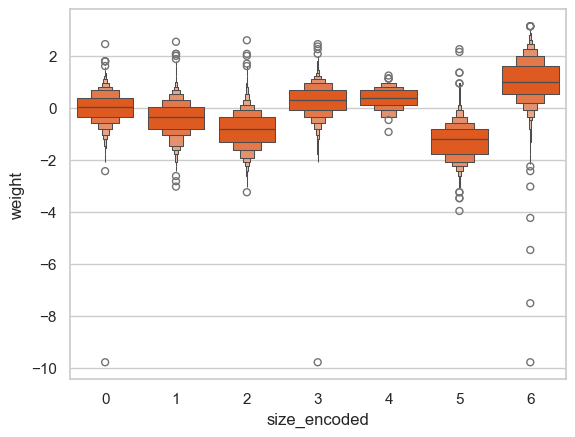

In [38]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='whitegrid',palette=cl1)
sns.boxenplot(data=df2,x=df2['size_encoded'],y=df2['weight'])
plt.savefig("p1.png",dpi=100)
plt.show()

In [40]:
df3.columns

Index(['weight', 'age', 'height', 'size_encoded'], dtype='object')

In [41]:
df3.sample(10)

,weight,age,height,size_encoded
47858,-0.680257,-0.977254,-0.713178,2
13832,-1.173808,-0.025915,-0.069925,5
22855,-1.449826,1.026831,-1.042114,1
103604,-0.680257,1.026831,-1.042114,3
7991,0.952017,1.026831,1.162034,6
38354,-1.596181,2.124923,-0.389165,5
2469,0.680169,-0.323885,0.860534,3
599,0.819772,0.069817,0.860534,6
63854,0.210468,-1.467134,-0.713178,0
70049,1.077471,-0.323885,1.459409,6
